# xrt_toolkit tutorial

This notebook exercises the main functionality of the library on small problems:

1. **2D reconstruction** with basis orders 0, 1, 2 (voxels / linear / quadratic box-splines)
2. **3D reconstruction**
3. **Differentiation with respect to the acquisition geometry** (recovering a detector shift by gradient descent)

Each section plots its result next to the ground truth, so a quick visual scan
tells you the library works end to end. A CUDA GPU is required.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import drjit as dr
from drjit.cuda.ad import Array2f, Array3f, Float

import xrt_toolkit as xtk

rng = np.random.default_rng(0)

## Helpers

Rays are given as `(t, n)`: a point on the ray and its direction, in lattice
units. `parallel_rays_2d` builds a standard parallel-beam scan; `cg` solves the
normal equations $A^\top A f = A^\top y$ with the matched adjoint.

In [2]:
def parallel_rays_2d(N, n_angles, n_det):
    angles = np.linspace(0, np.pi, n_angles, endpoint=False)
    u = np.linspace(-0.7 * N, 0.7 * N, n_det)
    ca, sa = np.cos(angles), np.sin(angles)
    # detector axis (-sin, cos), beam direction (cos, sin), through the center
    t = np.stack([N / 2 - u[None] * sa[:, None], N / 2 + u[None] * ca[:, None]], 0)
    n = np.stack([np.broadcast_to(ca[:, None], t.shape[1:]),
                  np.broadcast_to(sa[:, None], t.shape[1:])], 0)
    return (Array2f(t.reshape(2, -1).astype(np.float32)),
            Array2f(n.reshape(2, -1).astype(np.float32)))


def parallel_rays_3d(N, n_angles, n_det):
    angles = np.linspace(0, np.pi, n_angles, endpoint=False)
    u = np.linspace(-0.7 * N, 0.7 * N, n_det)
    U, V = np.meshgrid(u, u, indexing="ij")
    ca, sa = np.cos(angles), np.sin(angles)
    sh = (len(angles), n_det, n_det)
    t = np.stack([N / 2 - U[None] * sa[:, None, None],
                  N / 2 + U[None] * ca[:, None, None],
                  np.broadcast_to(N / 2 + V, sh)], 0)
    n = np.stack([np.broadcast_to(ca[:, None, None], sh),
                  np.broadcast_to(sa[:, None, None], sh),
                  np.zeros(sh)], 0)
    return (Array3f(t.reshape(3, -1).astype(np.float32)),
            Array3f(n.reshape(3, -1).astype(np.float32)))


def cg(rays, knot, order, y, n_iter=30):
    b = xtk.xrt_adjoint(rays, knot, order, y)
    f = dr.zeros(Float, len(b))
    r, p = Float(b), Float(b)
    rs = dr.sum(r * r)
    for _ in range(n_iter):
        Ap = xtk.xrt_adjoint(rays, knot, order, xtk.xrt_apply(rays, knot, order, p))
        alpha = rs / dr.sum(p * Ap)
        f = dr.fma(alpha, p, f)
        r = dr.fma(-alpha, Ap, r)
        rs_new = dr.sum(r * r)
        p = dr.fma(rs_new / rs, p, r)
        rs = rs_new
        dr.eval(f, r, p, rs)
    return f


def psnr(rec, ref):
    rec, ref = np.asarray(rec), np.asarray(ref)
    return 10 * np.log10(ref.max() ** 2 / np.mean((rec - ref) ** 2))

## 1. 2D reconstruction, orders 0 / 1 / 2

A 128x128 phantom, 180 angles, 192 detector cells. For each basis order the
phantom is projected and reconstructed with the same order, checking the
forward/adjoint pair end to end; all three should recover the phantom.

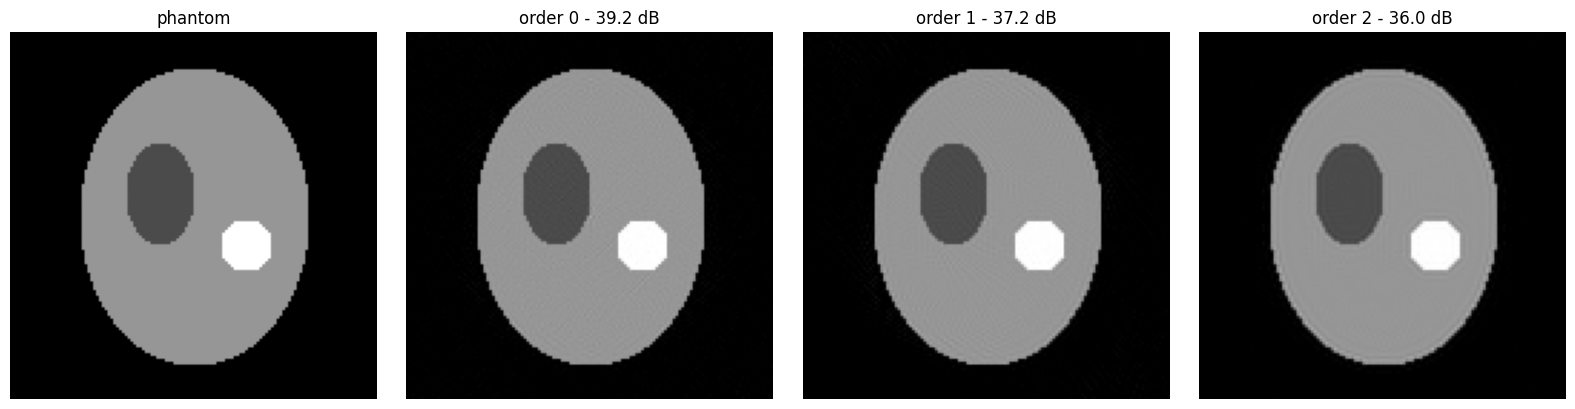

In [3]:
N = 128
yy, xx = np.mgrid[:N, :N]
phantom2d = ((((xx - 64) / 40) ** 2 + ((yy - 64) / 52) ** 2) < 1).astype(np.float32)
phantom2d -= 0.5 * ((((xx - 52) / 12) ** 2 + ((yy - 56) / 18) ** 2) < 1)
phantom2d += 0.7 * ((((xx - 82) / 9) ** 2 + ((yy - 74) / 9) ** 2) < 1)

knot2d = xtk.UniformSpec(start=0, step=1, num=(N, N))
rays2d = parallel_rays_2d(N, n_angles=180, n_det=192)
f_true = Float(phantom2d.reshape(-1))

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(phantom2d, cmap="gray")
axs[0].set_title("phantom")
for ax, order in zip(axs[1:], (0, 1, 2)):
    sino = xtk.xrt_apply(rays2d, knot2d, order, f_true)
    rec = np.asarray(cg(rays2d, knot2d, order, sino)).reshape(N, N)
    ax.imshow(rec, cmap="gray", vmin=phantom2d.min(), vmax=phantom2d.max())
    ax.set_title(f"order {order} - {psnr(rec, phantom2d):.1f} dB")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

## 2. 3D reconstruction

A 32x32x32 phantom of three spheres, 60 angles, 48x48 detector.

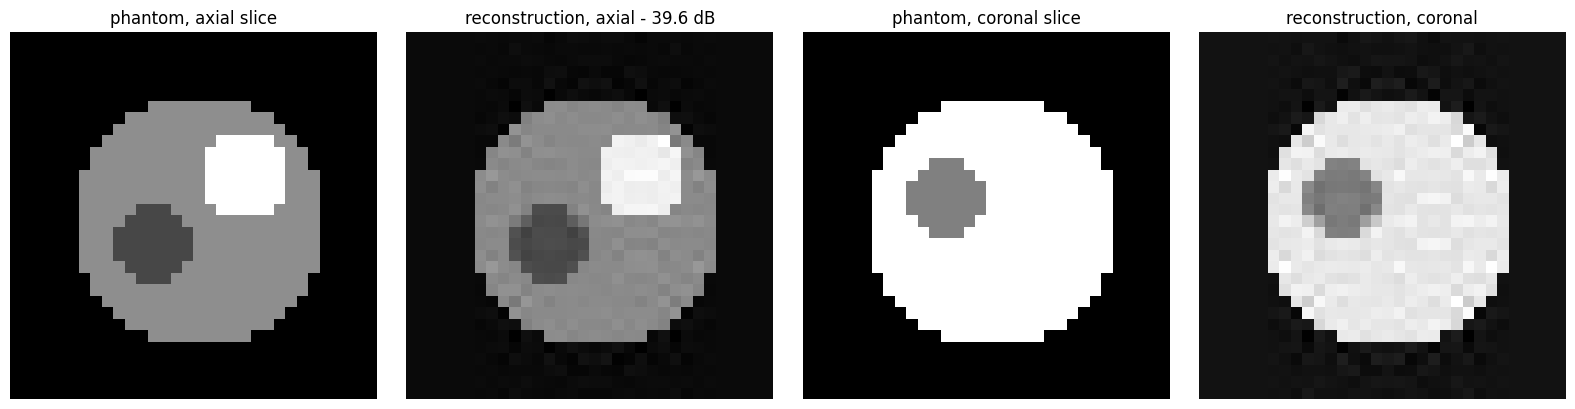

In [4]:
N3 = 32
zz, yy, xx = np.mgrid[:N3, :N3, :N3]
phantom3d = ((xx - 16) ** 2 + (yy - 16) ** 2 + (zz - 16) ** 2 < 11 ** 2).astype(np.float32)
phantom3d += 0.8 * ((xx - 20) ** 2 + (yy - 12) ** 2 + (zz - 16) ** 2 < 4 ** 2)
phantom3d -= 0.5 * ((xx - 12) ** 2 + (yy - 18) ** 2 + (zz - 14) ** 2 < 4 ** 2)

knot3d = xtk.UniformSpec(start=0, step=1, num=(N3, N3, N3))
rays3d = parallel_rays_3d(N3, n_angles=60, n_det=48)
sino3d = xtk.xrt_apply(rays3d, knot3d, 0, Float(phantom3d.reshape(-1)))

rec3d = np.asarray(cg(rays3d, knot3d, 0, sino3d)).reshape(N3, N3, N3)

fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(phantom3d[16], cmap="gray")
axs[0].set_title("phantom, axial slice")
axs[1].imshow(rec3d[16], cmap="gray")
axs[1].set_title(f"reconstruction, axial - {psnr(rec3d, phantom3d):.1f} dB")
axs[2].imshow(phantom3d[:, 16], cmap="gray")
axs[2].set_title("phantom, coronal slice")
axs[3].imshow(rec3d[:, 16], cmap="gray")
axs[3].set_title("reconstruction, coronal")
for ax in axs:
    ax.axis("off")
plt.tight_layout()

## 3. Differentiating through the geometry

The projection is differentiable with respect to the ray parameters
(`xrt_ad_t_*` for the ray origins, `xrt_ad_n_*` for the directions). Here the
data was acquired with a detector shifted by 1.5 lattice units; treating the
shift as an unknown and following the gradient of the data misfit recovers it.

recovered shift: 1.5000  (true 1.5)


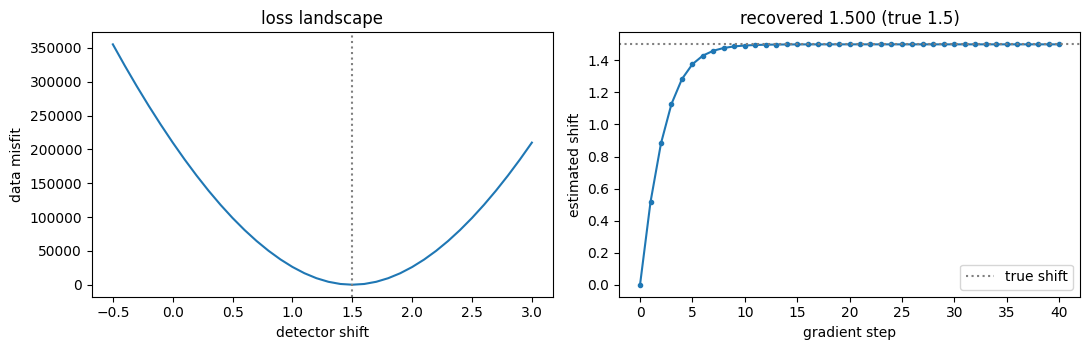

In [5]:
shift_true = 1.5
t0, n0 = rays2d
det_x, det_y = -np.sin(0), np.cos(0)  # per-ray detector axis, recomputed below

# per-ray detector axis (perpendicular to the beam direction)
nx, ny = np.asarray(n0[0]), np.asarray(n0[1])
ux, uy = -ny, nx

def shifted_rays(s):
    t = Array2f(np.asarray(t0[0]) + s * ux, np.asarray(t0[1]) + s * uy)
    return (t, n0)

y_meas = xtk.xrt_apply(shifted_rays(shift_true), knot2d, 1, f_true)

def loss_and_grad(s):
    rays = shifted_rays(s)
    resid = xtk.xrt_apply(rays, knot2d, 1, f_true) - y_meas
    gx = xtk.xrt_ad_t_x(rays, knot2d, 1, f_true)
    gy = xtk.xrt_ad_t_y(rays, knot2d, 1, f_true)
    g = dr.sum(resid * (Float(ux) * gx + Float(uy) * gy))
    return 0.5 * float(dr.sum(resid * resid).item()), float(g.item())

s, lr = 0.0, 2e-6
path = [s]
for it in range(40):
    L, g = loss_and_grad(s)
    s -= lr * g
    path.append(s)

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
ss = np.linspace(-0.5, 3.0, 36)
axs[0].plot(ss, [loss_and_grad(v)[0] for v in ss], "-")
axs[0].axvline(shift_true, color="gray", ls=":")
axs[0].set_xlabel("detector shift"); axs[0].set_ylabel("data misfit")
axs[0].set_title("loss landscape")
axs[1].plot(path, "o-", ms=3)
axs[1].axhline(shift_true, color="gray", ls=":", label="true shift")
axs[1].set_xlabel("gradient step"); axs[1].set_ylabel("estimated shift")
axs[1].set_title(f"recovered {path[-1]:.3f} (true {shift_true})")
axs[1].legend()
plt.tight_layout()
print(f"recovered shift: {path[-1]:.4f}  (true {shift_true})")